# Autoresearch 实验分析

对 `results.tsv` 中自主超参数调优结果的分析。


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取 TSV（制表符分隔，共 5 列：commit、val_bpb、memory_gb、status、description）
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"实验总数: {len(df)}")
print(f"列名: {list(df.columns)}")
df.head(10)


实验总数: 27
列名: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,2b0d03f,1.059162,26.4,KEEP,baseline
1,fc4dcc8,1.060413,26.4,DISCARD,shorten LR warmdown to last quarter
2,9b7acfc,1.048669,33.9,KEEP,increase width from 384 to 512
3,a1f644c,1.045843,39.0,KEEP,add one more 512d layer
4,6b66308,1.048791,39.0,DISCARD,use full attention windows
5,acf31a9,1.050510,43.8,DISCARD,add an eighth 512d layer
6,154b430,1.044496,39.0,KEEP,add 5 percent warmup
7,6dcba6e,1.047385,39.0,DISCARD,increase warmup to 10 percent
8,eff7f41,1.044096,39.0,KEEP,keep 10 percent final LR
9,ade3ad7,1.045507,39.0,DISCARD,keep 20 percent final LR


In [2]:
counts = df["status"].value_counts()
print("实验结果分布:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\n保留率: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")


实验结果分布:
status
DISCARD    14
KEEP       13

保留率: 13/27 = 48.1%


In [3]:
# 显示所有被保留（KEEP）的实验，也就是最终留下来的改进
kept = df[df["status"] == "KEEP"].copy()
print(f"保留实验（共 {len(kept)} 个）:\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")


保留实验（共 13 个）:

  #  0  bpb=1.059162  mem=26.4GB  baseline
  #  2  bpb=1.048669  mem=33.9GB  increase width from 384 to 512
  #  3  bpb=1.045843  mem=39.0GB  add one more 512d layer
  #  6  bpb=1.044496  mem=39.0GB  add 5 percent warmup
  #  8  bpb=1.044096  mem=39.0GB  keep 10 percent final LR
  # 14  bpb=1.043840  mem=39.0GB  use short windows in all intermediate layers
  # 15  bpb=1.039225  mem=39.0GB  reduce short attention window to quarter context
  # 16  bpb=1.036225  mem=39.0GB  reduce short attention window to eighth context
  # 18  bpb=1.036115  mem=39.0GB  raise Muon matrix LR slightly on 1/8 context
  # 20  bpb=1.031060  mem=19.7GB  try smaller total batch with 64 device batch
  # 22  bpb=1.030021  mem=19.7GB  lower final LR fraction on small batch setup
  # 24  bpb=1.029867  mem=19.7GB  start warmdown earlier on small batch setup
  # 25  bpb=1.029759  mem=19.7GB  start warmdown even earlier on small batch setup


## Val BPB 随时间变化

跟踪最佳（被保留的）`val_bpb` 如何随着实验推进而演化。运行最小值代表当前的“前沿”，也就是到目前为止取得的最好结果。


C:\Users\lihao\AppData\Local\Temp\ipykernel_17236\1690058980.py:55: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lihao\AppData\Local\Temp\ipykernel_17236\1690058980.py:55: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lihao\AppData\Local\Temp\ipykernel_17236\1690058980.py:55: UserWarning: Glyph 32534 (\N{CJK UNIFIED IDEOGRAPH-7F16}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lihao\AppData\Local\Temp\ipykernel_17236\1690058980.py:55: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lihao\AppData\Local\Temp\ipykernel_17236\1690058980.py:55: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lihao\AppData\Local\Temp\ipykernel_17236\1690058980.py:55: UserWarning: Glyph 65288 (\

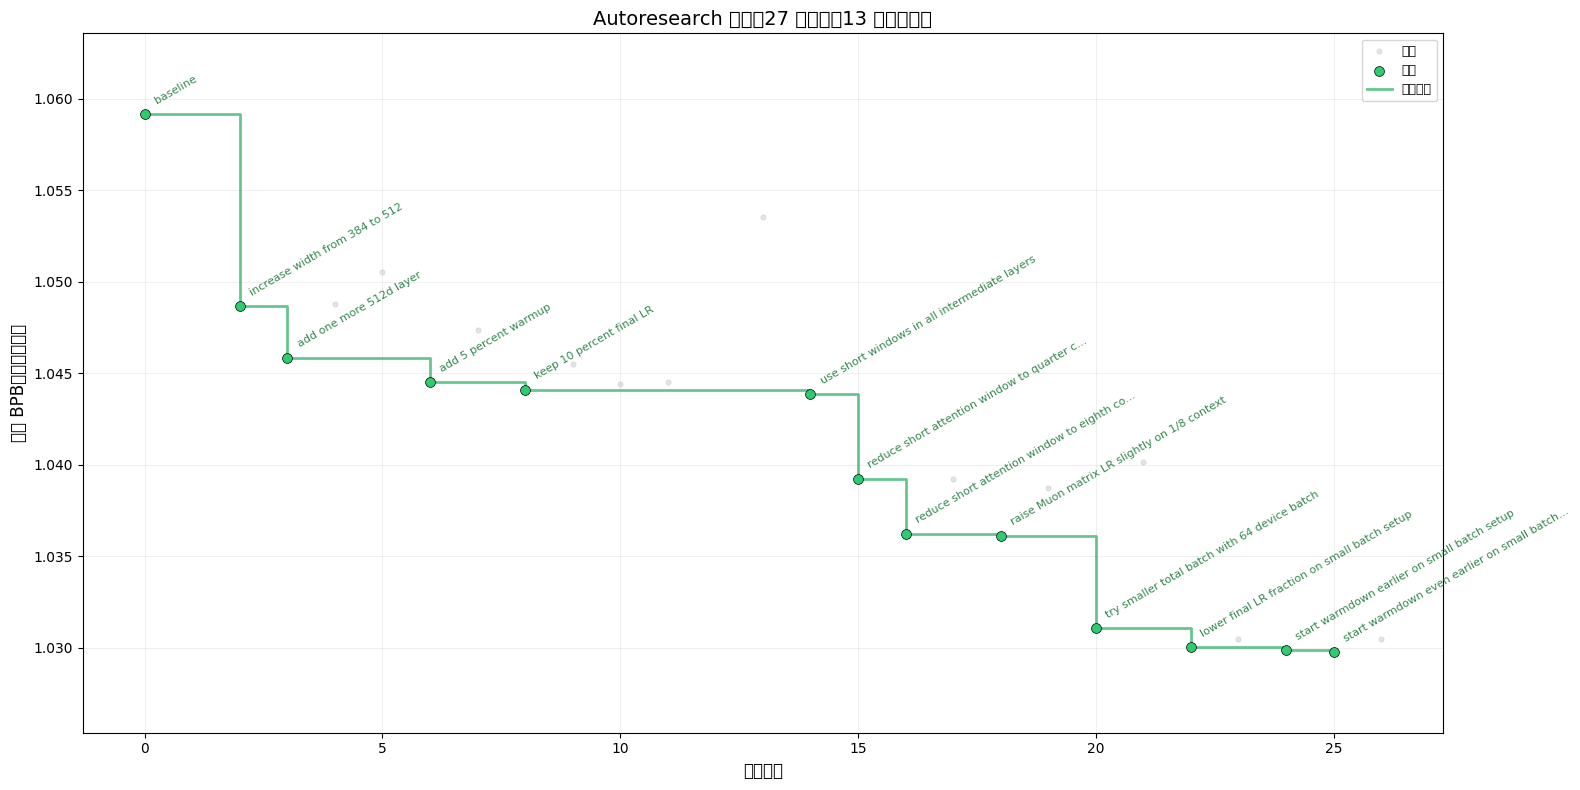

已保存到 progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# 为绘图过滤掉崩溃的实验
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# 只绘制不高于 baseline 太多的点（更有信息量的区域）
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# 将被丢弃的实验画成浅色背景点
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="丢弃")

# 将被保留的实验画成更醒目的绿色点
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="保留", edgecolors="black", linewidths=0.5)

# 运行最小值阶梯线
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="当前最优")

# 给每个保留实验标注描述
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("实验编号", fontsize=12)
ax.set_ylabel("验证 BPB（越低越好）", fontsize=12)
ax.set_title(f"Autoresearch 进展：{n_total} 次实验，{n_kept} 次保留改进", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y 轴范围：从略低于最佳值到略高于 baseline
best_bpb = kept_bpb.min()
margin = (baseline_bpb - best_bpb) * 0.15
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("已保存到 progress.png")


## 汇总统计


In [5]:
# 汇总统计
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"最佳 val_bpb:      {best_bpb:.6f}")
print(f"总改进幅度:       {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"最佳实验:         {best_row['description']}")
print()

# 找到每一次改进用了多少实验
print("每次改进对应的累计实验成本:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  实验 #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")


Baseline val_bpb:  1.059162
最佳 val_bpb:      1.029759
总改进幅度:       0.029403 (2.78%)
最佳实验:         start warmdown even earlier on small batch setup

每次改进对应的累计实验成本:
  实验 #  0: bpb=1.059162  baseline
  实验 #  2: bpb=1.048669  increase width from 384 to 512
  实验 #  3: bpb=1.045843  add one more 512d layer
  实验 #  6: bpb=1.044496  add 5 percent warmup
  实验 #  8: bpb=1.044096  keep 10 percent final LR
  实验 # 14: bpb=1.043840  use short windows in all intermediate layers
  实验 # 15: bpb=1.039225  reduce short attention window to quarter context
  实验 # 16: bpb=1.036225  reduce short attention window to eighth context
  实验 # 18: bpb=1.036115  raise Muon matrix LR slightly on 1/8 context
  实验 # 20: bpb=1.031060  try smaller total batch with 64 device batch
  实验 # 22: bpb=1.030021  lower final LR fraction on small batch setup
  实验 # 24: bpb=1.029867  start warmdown earlier on small batch setup
  实验 # 25: bpb=1.029759  start warmdown even earlier on small batch setup


## 最佳命中（按改进幅度排序的保留实验）


In [6]:
# 每个保留实验的增量，都是相对于上一个保留实验的 bpb 计算
# （因为实验是累积推进的，每次都建立在上一个保留状态之上）
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# 去掉 baseline（没有 delta）
hits = kept.iloc[1:].copy()

# 按改进量排序（最大的排前面）
hits = hits.sort_values("delta", ascending=False)

print("排名  改进量       BPB         描述")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n总计  {hits['delta'].sum():+.6f}              相对 baseline 的总改进")


排名  改进量       BPB         描述
--------------------------------------------------------------------------------
   1  +0.010493  1.048669  increase width from 384 to 512
   2  +0.005055  1.031060  try smaller total batch with 64 device batch
   3  +0.004615  1.039225  reduce short attention window to quarter context
   4  +0.003000  1.036225  reduce short attention window to eighth context
   5  +0.002826  1.045843  add one more 512d layer
   6  +0.001347  1.044496  add 5 percent warmup
   7  +0.001039  1.030021  lower final LR fraction on small batch setup
   8  +0.000400  1.044096  keep 10 percent final LR
   9  +0.000256  1.043840  use short windows in all intermediate layers
  10  +0.000154  1.029867  start warmdown earlier on small batch setup
  11  +0.000110  1.036115  raise Muon matrix LR slightly on 1/8 context
  12  +0.000108  1.029759  start warmdown even earlier on small batch setup

总计  +0.029403              相对 baseline 的总改进
